# HVAC Electircity Demand Analysis and Prediction

## Feature Creation and lag features

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor

np.random.seed(42)


In [9]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df["Day_of_Week"] = df["Time"].dt.weekday
df["Is_Workday"] = df["Day_of_Week"] < 5
df["Is_Workday"] = df["Is_Workday"].astype(int)
df["day_of_month"] = df["Time"].dt.day
df.set_index("Time", inplace=True)

df_daily = pd.read_csv("./data/df_daily_feature_creation.csv")
df_daily["Time"] = pd.to_datetime(df_daily["Time"])
df_daily.set_index("Time", inplace=True)

In [10]:
lag_days = np.arange(1, 61, 1)

for lag in lag_days:
    df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
        "electricity_demand_values"
    ].shift(lag)
df_daily.dropna(inplace=True)



In [11]:
def train_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_pred - y_test))
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    df_results = pd.DataFrame(
        {"Time": y_test.index, "y_test": y_test, "y_pred": y_pred}
    )
    return df_results

In [12]:
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test

In [13]:
def plot_results(df_results, model_name):
    _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df_results["Time"], df_results["y_test"], label="Test")
    ax.plot(df_results["Time"], df_results["y_pred"], label="Predicted")
    ax.set_title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [20]:
def corr_features_plot(df_daily, threshold):
    correlations = df_daily.corr()["electricity_demand_values"]
    correlated_features = correlations[abs(correlations) > threshold].index
    _, ax = plt.subplots(figsize=(16, 16))
    sns.heatmap(
        df_daily.corr().loc[correlated_features, correlated_features], annot=True, ax=ax
    )
    ax.set_title(f"Correlation Matrix of Daily Data (abs(corr) >= {threshold})")
    plt.tight_layout()
    plt.show()

In [31]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.5].index

In [32]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily[correlated_features], "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 13), (516,), (172, 13), (172,))

In [33]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 1902.5546
MAE: 928.5443
R2: 0.7331


In [34]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 1270.1697
MAE: 859.2591
R2: 0.8810


In [35]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 713.2980
MAE: 425.9990
R2: 0.9625


In [36]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_daily[correlated_features].drop("electricity_demand_values", axis=1),
    df_daily[correlated_features]["electricity_demand_values"],
    test_size=0.2,
    random_state=42,
)

In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []

for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mae_ls.append(mae)
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R^2 Score: {r2}")

RMSE: 487.35069046814965
MAE: 306.43495314261304
R^2 Score: 0.9760003291216723
RMSE: 497.31446679500607
MAE: 294.72401872105905
R^2 Score: 0.9754156754424674
RMSE: 590.0917909689744
MAE: 326.05467694150224
R^2 Score: 0.9692222274443031
RMSE: 380.93332072106006
MAE: 277.2219372385046
R^2 Score: 0.9868560765744389
RMSE: 406.51193946925514
MAE: 280.4197430194061
R^2 Score: 0.982963797143459


In [38]:
# Use KFold + cross_val_score to calculate RMSE, MAE, and R-squared scores
mse_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
)
mae_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
)
r2_scores = cross_val_score(ada_reg, X_trainval, y_trainval, cv=kf, scoring="r2")

# Calculate the RMSE, MAE, and R-squared scores' mean
rmse_scores = np.sqrt(mse_scores)
mean_rmse = rmse_scores.mean()
mean_mae = mae_scores.mean()
mean_r2 = r2_scores.mean()

In [39]:
# Print the results
print("Mean RMSE:", round(mean_rmse, 4))
print("Mean MAE:", round(mean_mae, 4))
print("Mean R-squared score:", round(mean_r2, 4))

Mean RMSE: 472.4404
Mean MAE: 296.9711
Mean R-squared score: 0.9781


In [40]:
y_pred = ada_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
r2 = r2_score(y_test, y_pred)  # Calculating R2 score
print(f"Training on test set: RMSE: {rmse:.4f},MAE: {mae:.4f}, R2: {r2:.4f}")

df_results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

Training on test set: RMSE: 505.4839,MAE: 289.1650, R2: 0.9775


<Axes: xlabel='Time'>

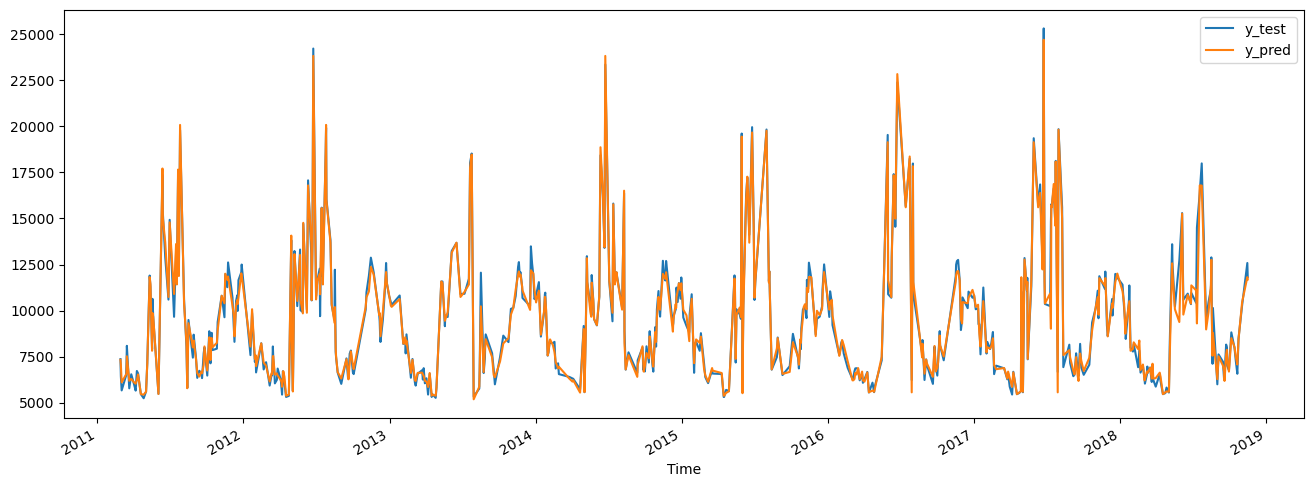

In [41]:
df_results.plot(figsize=(16, 6))

In [ ]:
#0.3

In [43]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.3].index

In [44]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_daily[correlated_features].drop("electricity_demand_values", axis=1),
    df_daily[correlated_features]["electricity_demand_values"],
    test_size=0.2,
    random_state=42,
)

In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []

for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mae_ls.append(mae)
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R^2 Score: {r2}")

RMSE: 351.94647845024474
MAE: 229.63979242546165
R^2 Score: 0.9874837173319809
RMSE: 448.3714901547823
MAE: 226.53164402702225
R^2 Score: 0.9800164760695214
RMSE: 523.7793331590324
MAE: 264.57434392593547
R^2 Score: 0.9757509484529857
RMSE: 305.2494586541603
MAE: 220.04929994888474
R^2 Score: 0.991560107793148
RMSE: 291.2925621025966
MAE: 207.2760228443639
R^2 Score: 0.9912524792271274


In [46]:
# Use KFold + cross_val_score to calculate RMSE, MAE, and R-squared scores
mse_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
)
mae_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
)
r2_scores = cross_val_score(ada_reg, X_trainval, y_trainval, cv=kf, scoring="r2")

# Calculate the RMSE, MAE, and R-squared scores' mean
rmse_scores = np.sqrt(mse_scores)
mean_rmse = rmse_scores.mean()
mean_mae = mae_scores.mean()
mean_r2 = r2_scores.mean()

In [47]:
# Print the results
print("Mean RMSE:", round(mean_rmse, 4))
print("Mean MAE:", round(mean_mae, 4))
print("Mean R-squared score:", round(mean_r2, 4))

Mean RMSE: 384.1279
Mean MAE: 229.6142
Mean R-squared score: 0.9852


In [48]:
y_pred = ada_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
r2 = r2_score(y_test, y_pred)  # Calculating R2 score
print(f"Training on test set: RMSE: {rmse:.4f},MAE: {mae:.4f}, R2: {r2:.4f}")

df_results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

Training on test set: RMSE: 357.7375,MAE: 221.7121, R2: 0.9887


<Axes: xlabel='Time'>

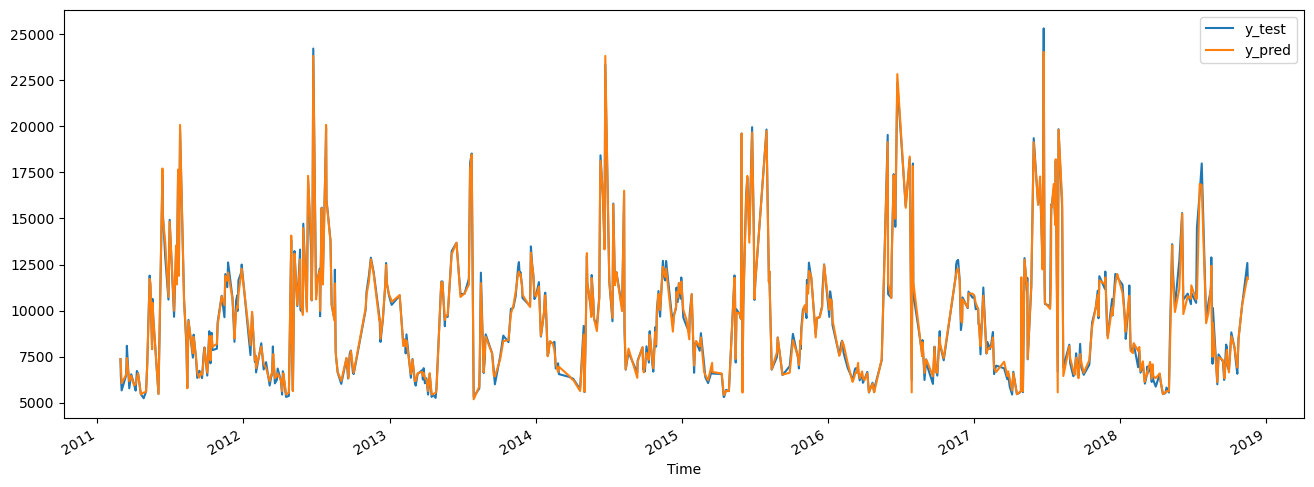

In [49]:
df_results.plot(figsize=(16, 6))

In [50]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.1].index

In [51]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_daily[correlated_features].drop("electricity_demand_values", axis=1),
    df_daily[correlated_features]["electricity_demand_values"],
    test_size=0.2,
    random_state=42,
)

In [52]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []

for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mae_ls.append(mae)
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R^2 Score: {r2}")

RMSE: 437.0754028287884
MAE: 236.58426411709632
R^2 Score: 0.9806965538843845
RMSE: 413.9995352832685
MAE: 232.1680974452455
R^2 Score: 0.9829628949180763
RMSE: 444.56419289652393
MAE: 235.00227398276192
R^2 Score: 0.9825310420440372
RMSE: 282.1970000277508
MAE: 203.35521145114853
R^2 Score: 0.9927867351220034
RMSE: 377.06070403496125
MAE: 220.8056183345827
R^2 Score: 0.9853428767506743


In [53]:
# Use KFold + cross_val_score to calculate RMSE, MAE, and R-squared scores
mse_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
)
mae_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
)
r2_scores = cross_val_score(ada_reg, X_trainval, y_trainval, cv=kf, scoring="r2")

# Calculate the RMSE, MAE, and R-squared scores' mean
rmse_scores = np.sqrt(mse_scores)
mean_rmse = rmse_scores.mean()
mean_mae = mae_scores.mean()
mean_r2 = r2_scores.mean()

In [54]:
# Print the results
print("Mean RMSE:", round(mean_rmse, 4))
print("Mean MAE:", round(mean_mae, 4))
print("Mean R-squared score:", round(mean_r2, 4))

Mean RMSE: 390.9794
Mean MAE: 225.5831
Mean R-squared score: 0.9849


In [55]:
y_pred = ada_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
r2 = r2_score(y_test, y_pred)  # Calculating R2 score
print(f"Training on test set: RMSE: {rmse:.4f},MAE: {mae:.4f}, R2: {r2:.4f}")

df_results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

Training on test set: RMSE: 281.5357,MAE: 207.7976, R2: 0.9930


<Axes: xlabel='Time'>

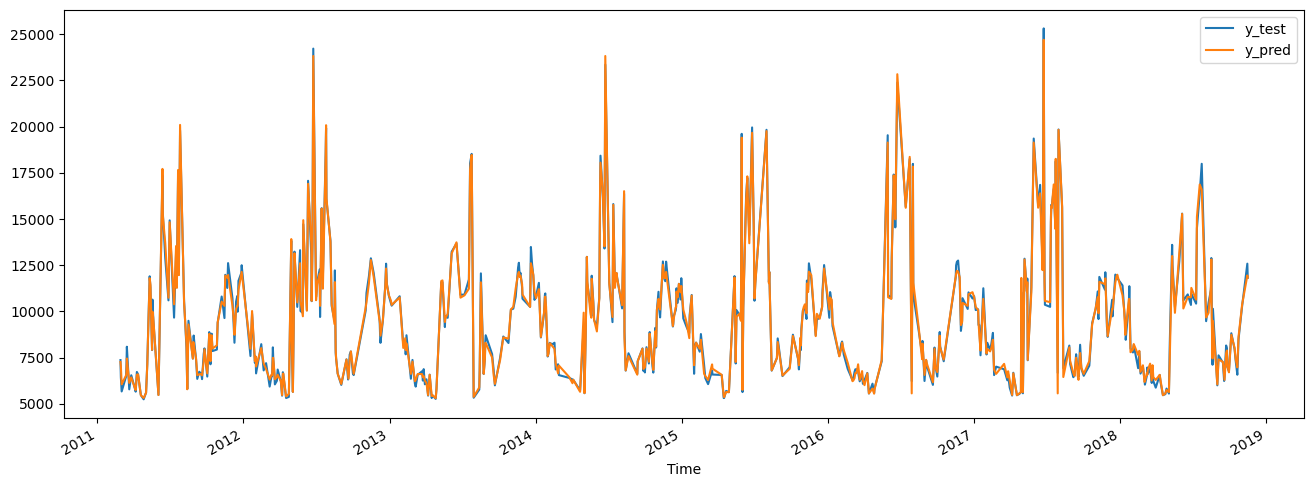

In [56]:
df_results.plot(figsize=(16, 6))

In [57]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.8].index

In [64]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_daily.drop("electricity_demand_values", axis=1),
    df_daily["electricity_demand_values"],
    test_size=0.2,
    random_state=42,
)

In [65]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []

for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mae_ls.append(mae)
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R^2 Score: {r2}")

RMSE: 366.79436321766957
MAE: 227.62068676773995
R^2 Score: 0.9864053691093039
RMSE: 434.4394441681353
MAE: 233.5159393588285
R^2 Score: 0.9812390600409866
RMSE: 475.20876506661904
MAE: 248.81359532499116
R^2 Score: 0.9800397064133788
RMSE: 310.91053413389295
MAE: 228.66283076454457
R^2 Score: 0.9912441569368826
RMSE: 392.44056197746005
MAE: 223.21491802384773
R^2 Score: 0.9841227980252899


In [66]:
# Use KFold + cross_val_score to calculate RMSE, MAE, and R-squared scores
mse_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
)
mae_scores = -cross_val_score(
    ada_reg, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
)
r2_scores = cross_val_score(ada_reg, X_trainval, y_trainval, cv=kf, scoring="r2")

# Calculate the RMSE, MAE, and R-squared scores' mean
rmse_scores = np.sqrt(mse_scores)
mean_rmse = rmse_scores.mean()
mean_mae = mae_scores.mean()
mean_r2 = r2_scores.mean()

In [67]:
# Print the results
print("Mean RMSE:", round(mean_rmse, 4))
print("Mean MAE:", round(mean_mae, 4))
print("Mean R-squared score:", round(mean_r2, 4))

Mean RMSE: 395.9587
Mean MAE: 232.3656
Mean R-squared score: 0.9846


In [68]:
y_pred = ada_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
r2 = r2_score(y_test, y_pred)  # Calculating R2 score
print(f"Training on test set: RMSE: {rmse:.4f},MAE: {mae:.4f}, R2: {r2:.4f}")

df_results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

Training on test set: RMSE: 325.4706,MAE: 214.2260, R2: 0.9907


<Axes: xlabel='Time'>

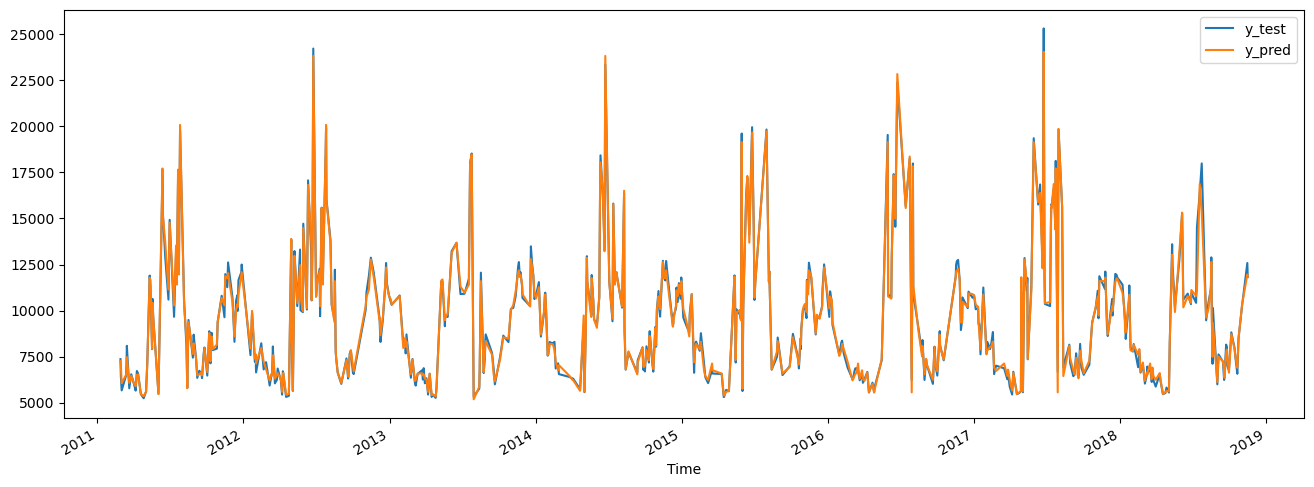

In [69]:
df_results.plot(figsize=(16, 6))